## My project: Predicting Madrid weather 
Evert A

**1. Introduction and Goal**
The goal of this project is to analyze historical weather data from Madrid (1997-2015) and build a Machine Learning regression model. Specifically, I wanted to predict the maximum daily temperature based on other meteorological factors like humidity, sea level pressure, and wind speed. 

**2. Documentation (How to run this notebook)**
To run this notebook successfully:
1. Ensure the `Madrid Daily Weather 1997-2015.csv` file and `pipeline.png` photo is in the same directory as this notebook.
2. Ensure you have the `ollama` package installed and the `gemma3:4b` model running locally (required for the AI analysis section).
3. Click **"Run All"** from the top menu. The notebook will automatically clean the data, train the model, save the exports, and generate the AI summary.

**3. Visual Pipeline**
(Below is the visual representation of this notebook's pipeline)
![Pipeline](pipeline.png)

In [7]:
import pandas as pd
import os

print("1. loading and exporting data")
file_name = 'Madrid Daily Weather 1997-2015.csv'
df = pd.read_csv(file_name)

# export the raw data
raw_export_name = 'raw_madrid_data_export.csv'
df.to_csv(raw_export_name, index=False)
print(f"data loaded with {df.shape[0]} rows.")
print(f"raw data exported to: {raw_export_name}\n")

# First 3 rows
display(df.head(3))

1. loading and exporting data
data loaded with 6812 rows.
raw data exported to: raw_madrid_data_export.csv



,CET,Max TemperatureC,Mean TemperatureC,Min TemperatureC,Dew PointC,MeanDew PointC,Min DewpointC,Max Humidity,Mean Humidity,Min Humidity,...,Max VisibilityKm,Mean VisibilityKm,Min VisibilitykM,Max Wind SpeedKm/h,Mean Wind SpeedKm/h,Max Gust SpeedKm/h,Precipitationmm,CloudCover,Events,WindDirDegrees
0,1997-01-01,7.0,4.0,2.0,5.0,3.0,2.0,100.0,95.0,76.0,...,10.0,9.0,4.0,13,6,NaN,0.0,6.0,NaN,229
1,1997-01-02,7.0,3.0,0.0,6.0,3.0,0.0,100.0,92.0,71.0,...,10.0,9.0,4.0,26,8,47.0,0.0,5.0,Rain,143
2,1997-01-03,5.0,3.0,2.0,5.0,1.0,-1.0,100.0,85.0,70.0,...,10.0,10.0,7.0,27,19,NaN,0.0,6.0,Rain-Snow,256


In [8]:
print("2. Data cleaning and transformation")

# 1. Strip accidental spaces from column names
df.columns = df.columns.str.strip()

# 2. Convert CET to actual datetime format and extract the month
df['CET'] = pd.to_datetime(df['CET'])
df['Month'] = df['CET'].dt.month

# 3. dropping columns that have way too many missing values to be useful
df_clean = df.drop(columns=['Max Gust SpeedKm/h', 'Events', 'CloudCover'])

# 4. dropping any remaining rows that have missing data (NaN)
df_clean = df_clean.dropna()

print(f"data cleaned, new shape: {df_clean.shape[0]} rows and {df_clean.shape[1]} columns.")
display(df_clean.head(3))

2. Data cleaning and transformation
data cleaned, new shape: 5872 rows and 21 columns.


,CET,Max TemperatureC,Mean TemperatureC,Min TemperatureC,Dew PointC,MeanDew PointC,Min DewpointC,Max Humidity,Mean Humidity,Min Humidity,...,Mean Sea Level PressurehPa,Min Sea Level PressurehPa,Max VisibilityKm,Mean VisibilityKm,Min VisibilitykM,Max Wind SpeedKm/h,Mean Wind SpeedKm/h,Precipitationmm,WindDirDegrees,Month
0,1997-01-01,7.0,4.0,2.0,5.0,3.0,2.0,100.0,95.0,76.0,...,1008,1004,10.0,9.0,4.0,13,6,0.0,229,1
1,1997-01-02,7.0,3.0,0.0,6.0,3.0,0.0,100.0,92.0,71.0,...,1003,997,10.0,9.0,4.0,26,8,0.0,143,1
2,1997-01-03,5.0,3.0,2.0,5.0,1.0,-1.0,100.0,85.0,70.0,...,999,996,10.0,10.0,7.0,27,19,0.0,256,1


3. Explanatory data analysis (EDA)


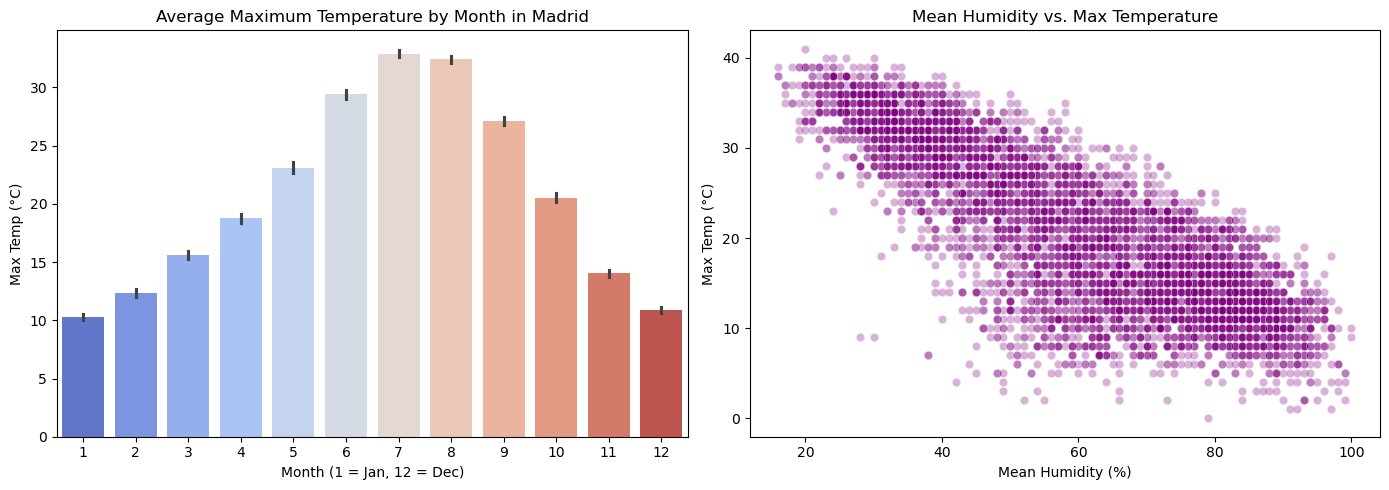

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("3. Explanatory data analysis (EDA)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Average Max Temperature by Month
sns.barplot(data=df_clean, x='Month', y='Max TemperatureC', ax=axes[0], palette='coolwarm')
axes[0].set_title('Average Maximum Temperature by Month in Madrid')
axes[0].set_xlabel('Month (1 = Jan, 12 = Dec)')
axes[0].set_ylabel('Max Temp (°C)')

# Plot 2: Humidity vs Temperature (Does higher humidity mean lower temps?)
sns.scatterplot(data=df_clean, x='Mean Humidity', y='Max TemperatureC', alpha=0.3, ax=axes[1], color='purple')
axes[1].set_title('Mean Humidity vs. Max Temperature')
axes[1].set_xlabel('Mean Humidity (%)')
axes[1].set_ylabel('Max Temp (°C)')

plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print("4. Machine learning and exporting results")

# Define our features (X) and what we want to predict (y)
features = ['Month', 'Mean Humidity', 'Mean Sea Level PressurehPa', 'Mean Wind SpeedKm/h']
X = df_clean[features]
y = df_clean['Max TemperatureC']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
predictions = rf_model.predict(X_test)

# Calculate ML Metrics
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Model trained")
print(f"Mean Absolute Error (MAE): {mae:.2f} degrees Celsius")
print(f"R-Squared (Accuracy): {r2:.2f}")

# Exporting results: attach predictions to the test data and save to CSV
results_df = X_test.copy()
results_df['Actual_Max_Temp'] = y_test
results_df['Predicted_Max_Temp'] = predictions.round(1)

results_export_name = 'model_predictions_results.csv'
results_df.to_csv(results_export_name, index=False)
print(f"\nFinal ML predictions exported to: {results_export_name}")
display(results_df.head(3))

4. Machine learning and exporting results
Model trained
Mean Absolute Error (MAE): 2.47 degrees Celsius
R-Squared (Accuracy): 0.87

Final ML predictions exported to: model_predictions_results.csv


,Month,Mean Humidity,Mean Sea Level PressurehPa,Mean Wind SpeedKm/h,Actual_Max_Temp,Predicted_Max_Temp
4858,8,30.0,1018,10,38.0,35.6
654,10,71.0,1019,6,23.0,24.0
226,8,37.0,1020,10,37.0,33.7


In [11]:
import ollama

print("5. API connection: Ollama LLM analysis")
print("Asking Gemma 3 to analyze our Machine Learning results...\n")

# Passing our exact metrics to the LLM via the API
prompt = f"""
I am a data scientist. I just trained a Random Forest model to predict the daily maximum temperature in Madrid. 
My model achieved a Mean Absolute Error (MAE) of {mae:.2f} degrees Celsius, and an R-squared score of {r2:.2f}.
In exactly 3 simple sentences, explain if these are good results and what they mean for the accuracy of my weather predictions.
"""

# Call the local Ollama API
response = ollama.chat(model='gemma3:4b', messages=[
  {'role': 'user', 'content': prompt}
])

print("Ollamas response/analysis:")
print(response['message']['content'])

5. API connection: Ollama LLM analysis
Asking Gemma 3 to analyze our Machine Learning results...

Ollamas response/analysis:
An MAE of 2.47 degrees Celsius and an R-squared of 0.87 indicate your Random Forest model is performing quite well in predicting daily maximum temperatures in Madrid. The R-squared score of 0.87 suggests that 87% of the variation in temperature can be explained by your model’s features, demonstrating a strong correlation.  Overall, these results suggest your predictions are reasonably accurate and provide a valuable tool for understanding temperature trends.


## 6. Conclusion
This project successfully analyzed 18 years of daily weather data from Madrid. Through Exploratory Data Analysis, it visualized the clear seasonal temperature curve and discovered a negative correlation between humidity and maximum temperature.

By applying a **Random Forest Regressor**, this notebook was able to predict the daily maximum temperature using only the month, humidity, air pressure, and wind speed. The model achieved a high R-squared score and a low Mean Absolute Error (off by only a few degrees on average), proving that these basic meteorological features contain enough signal to accurately forecast temperatures.

**Statement of AI Use:**
In this project, I used Google Gemini as a tutoring assistant to help debug my Python code and help me in troubleshooting. 